# Taller 04 — Programación genética para la ruta de un robot repartidor

**Curso:** Inteligencia Artificial y Minirobots 2026-1  
**Autor:** Juan Tinjacá  
**Fecha:** Marzo 2026

---

## 1. Objetivo

Diseñar una solución basada en programación genética (PG) para evolucionar programas-árbol que controlen un robot repartidor de galletas en un entorno 2D, maximizando el número de entregas exitosas a ingenieros distribuidos en la cuadrícula.

## 2. Supuestos

**Entorno:** cuadrícula 10×10. El robot inicia en (0,0). Los ingenieros están en posiciones fijas aleatorias.

**Representación de individuos:** cada individuo es un árbol-programa construido recursivamente con nodos función y nodos terminal. Al ejecutarse, el árbol produce una secuencia de movimientos para el robot.

**Terminales** (hojas del árbol — acciones atómicas del robot):

| Terminal | Descripción |
|----------|-------------|
| `NORTE`  | Mover una celda hacia arriba |
| `SUR`    | Mover una celda hacia abajo |
| `ESTE`   | Mover una celda hacia la derecha |
| `OESTE`  | Mover una celda hacia la izquierda |

**Funciones** (nodos internos del árbol — estructuras de control):

| Función | Aridad | Descripción |
|---------|--------|-------------|
| `SEQ(a, b)` | 2 | Ejecuta `a` y luego `b` en secuencia |
| `IF_INGENIERO(a, b)` | 2 | Si hay un ingeniero en la celda actual, ejecuta `a`; si no, ejecuta `b` |
| `REP3(a)` | 1 | Repite la acción `a` tres veces |

**Función de aptitud:** número de ingenieros visitados (entregados) durante la ejecución del programa. Cada ingeniero solo cuenta una vez.

**Operadores evolutivos:**
- Selección por torneo (tamaño 3)
- Cruce de subárboles (intercambio de un subárbol aleatorio entre dos padres)
- Mutación de subárbol (reemplazar un subárbol aleatorio por uno nuevo generado aleatoriamente)

**Restricciones de árbol:** profundidad máxima = 5, máximo 50 pasos de ejecución por individuo.

## 3. Desarrollo

### Instalación de dependencias

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "numpy", "-q"])
print("Dependencias listas.")

Dependencias listas.


### 3.1 Entorno y estado del robot

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import copy, random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Parámetros del entorno ────────────────────────────────────────────────
GRID         = 10          # Cuadrícula 10x10
N_INGENIEROS = 8           # Número de ingenieros
MAX_PASOS    = 50          # Pasos máximos por ejecución
PROF_MAX     = 5           # Profundidad máxima del árbol
POP_SIZE     = 80          # Tamaño de la población
N_GEN        = 60          # Generaciones
P_MUTACION   = 0.15        # Probabilidad de mutación

# Posiciones fijas de ingenieros (reproducibles)
random.seed(SEED)
INGENIEROS = list({(random.randint(0, GRID-1), random.randint(0, GRID-1))
                   for _ in range(N_INGENIEROS * 3)})[:N_INGENIEROS]
INICIO = (0, 0)

print(f"Entorno: {GRID}x{GRID} | Ingenieros: {len(INGENIEROS)}")
print(f"Posiciones: {INGENIEROS}")

Entorno: 10x10 | Ingenieros: 8
Posiciones: [(4, 0), (4, 3), (5, 4), (5, 1), (8, 9), (1, 0), (1, 6), (0, 8)]


### 3.2 Representación del árbol-programa

In [3]:
# ── Nodos del árbol ───────────────────────────────────────────────────────
TERMINALES = ["NORTE", "SUR", "ESTE", "OESTE"]
FUNCIONES  = {
    "SEQ":          2,   # aridad 2
    "IF_INGENIERO": 2,   # aridad 2
    "REP3":         1,   # aridad 1
}

class Nodo:
    """Nodo de un árbol-programa de programación genética."""
    def __init__(self, valor, hijos=None):
        self.valor  = valor
        self.hijos  = hijos or []

    def es_terminal(self):
        return self.valor in TERMINALES

    def __repr__(self):
        if self.es_terminal():
            return self.valor
        return f"{self.valor}({', '.join(repr(h) for h in self.hijos)})"


def arbol_aleatorio(prof_max, metodo="crecer"):
    """Genera un árbol aleatorio con el método 'crecer' o 'completo'."""
    if prof_max == 0 or (metodo == "crecer" and random.random() < 0.4):
        return Nodo(random.choice(TERMINALES))
    func   = random.choice(list(FUNCIONES.keys()))
    aridad = FUNCIONES[func]
    hijos  = [arbol_aleatorio(prof_max - 1, metodo) for _ in range(aridad)]
    return Nodo(func, hijos)


# Ejemplo
ejemplo = arbol_aleatorio(3)
print("Árbol de ejemplo:", ejemplo)

Árbol de ejemplo: ESTE


### 3.3 Simulación del robot (evaluación del árbol)

In [4]:
class EstadoRobot:
    """Estado mutable del robot durante la ejecución de un programa."""
    def __init__(self):
        self.x, self.y   = INICIO
        self.pasos       = 0
        self.entregados  = set()
        self.ruta        = [INICIO]

    def mover(self, direccion):
        if self.pasos >= MAX_PASOS:
            return
        dx, dy = {"NORTE": (0, 1), "SUR": (0, -1),
                  "ESTE":  (1, 0), "OESTE": (-1, 0)}[direccion]
        self.x = max(0, min(GRID - 1, self.x + dx))
        self.y = max(0, min(GRID - 1, self.y + dy))
        self.pasos += 1
        self.ruta.append((self.x, self.y))
        if (self.x, self.y) in INGENIEROS:
            self.entregados.add((self.x, self.y))


def ejecutar(nodo, estado):
    """Ejecuta recursivamente el árbol-programa sobre el estado del robot."""
    if estado.pasos >= MAX_PASOS:
        return
    v = nodo.valor
    if v in TERMINALES:
        estado.mover(v)
    elif v == "SEQ":
        ejecutar(nodo.hijos[0], estado)
        ejecutar(nodo.hijos[1], estado)
    elif v == "IF_INGENIERO":
        if (estado.x, estado.y) in INGENIEROS:
            ejecutar(nodo.hijos[0], estado)
        else:
            ejecutar(nodo.hijos[1], estado)
    elif v == "REP3":
        for _ in range(3):
            ejecutar(nodo.hijos[0], estado)


def evaluar(arbol):
    """Función de aptitud: número de ingenieros visitados."""
    estado = EstadoRobot()
    ejecutar(arbol, estado)
    return len(estado.entregados), estado

### 3.4 Operadores genéticos

In [5]:
def nodos_lista(arbol):
    """Retorna lista plana de todos los nodos del árbol (para selección aleatoria)."""
    resultado = [arbol]
    for hijo in arbol.hijos:
        resultado.extend(nodos_lista(hijo))
    return resultado


def cruce_subarboles(p1, p2):
    """Intercambia un subárbol aleatorio entre dos padres (copia profunda)."""
    h1, h2 = copy.deepcopy(p1), copy.deepcopy(p2)
    nodos1  = [n for n in nodos_lista(h1) if not n.es_terminal()]
    nodos2  = [n for n in nodos_lista(h2) if not n.es_terminal()]
    if not nodos1 or not nodos2:
        return h1, h2
    n1 = random.choice(nodos1)
    n2 = random.choice(nodos2)
    idx1 = random.randrange(len(n1.hijos))
    idx2 = random.randrange(len(n2.hijos))
    n1.hijos[idx1], n2.hijos[idx2] = n2.hijos[idx2], n1.hijos[idx1]
    return h1, h2


def mutacion_subarbol(arbol, prof_max=3):
    """Reemplaza un subárbol aleatorio por uno nuevo generado aleatoriamente."""
    mutante = copy.deepcopy(arbol)
    nodos   = [n for n in nodos_lista(mutante) if not n.es_terminal()]
    if not nodos:
        return arbol_aleatorio(prof_max)
    nodo = random.choice(nodos)
    idx  = random.randrange(len(nodo.hijos))
    nodo.hijos[idx] = arbol_aleatorio(prof_max)
    return mutante


def seleccion_torneo(poblacion, aptitudes, k=3):
    """Torneo de tamaño k: retorna el individuo con mayor aptitud del grupo."""
    candidatos = random.sample(range(len(poblacion)), k)
    mejor = max(candidatos, key=lambda i: aptitudes[i])
    return copy.deepcopy(poblacion[mejor])

## 4. Ejecución — Evolución de la población

In [6]:
random.seed(SEED)
np.random.seed(SEED)

# Población inicial con método ramped half-and-half
poblacion = [arbol_aleatorio(random.randint(2, PROF_MAX),
             metodo=random.choice(["crecer", "completo"]))
             for _ in range(POP_SIZE)]

historial_mejor = []
historial_media = []
mejor_arbol     = None
mejor_aptitud   = -1

for gen in range(N_GEN):
    aptitudes = [evaluar(ind)[0] for ind in poblacion]
    mejor_gen = max(aptitudes)
    historial_mejor.append(mejor_gen)
    historial_media.append(np.mean(aptitudes))

    if mejor_gen > mejor_aptitud:
        mejor_aptitud = mejor_gen
        mejor_arbol   = copy.deepcopy(poblacion[aptitudes.index(mejor_gen)])

    # Elitismo: conservar el mejor
    nueva_pob = [copy.deepcopy(poblacion[aptitudes.index(mejor_gen)])]

    while len(nueva_pob) < POP_SIZE:
        p1 = seleccion_torneo(poblacion, aptitudes)
        p2 = seleccion_torneo(poblacion, aptitudes)
        h1, _ = cruce_subarboles(p1, p2)
        if random.random() < P_MUTACION:
            h1 = mutacion_subarbol(h1)
        nueva_pob.append(h1)

    poblacion = nueva_pob

    if (gen + 1) % 15 == 0:
        print(f"Gen {gen+1:>3} | Mejor: {mejor_gen} entregas | Media: {historial_media[-1]:.2f}")

print(f"\nMejor solución encontrada: {mejor_aptitud} / {len(INGENIEROS)} entregas")
print(f"Árbol: {mejor_arbol}")

Gen  15 | Mejor: 6 entregas | Media: 4.20
Gen  30 | Mejor: 6 entregas | Media: 5.71
Gen  45 | Mejor: 6 entregas | Media: 5.50
Gen  60 | Mejor: 6 entregas | Media: 5.95

Mejor solución encontrada: 6 / 8 entregas
Árbol: SEQ(REP3(ESTE), SEQ(SEQ(REP3(REP3(SEQ(ESTE, REP3(REP3(IF_INGENIERO(NORTE, SEQ(IF_INGENIERO(REP3(OESTE), SEQ(SEQ(SUR, ESTE), NORTE)), REP3(SEQ(NORTE, OESTE))))))))), SUR), SEQ(REP3(ESTE), ESTE)))


## 5. Resultado

### 5.1 Curva de aptitud por generación

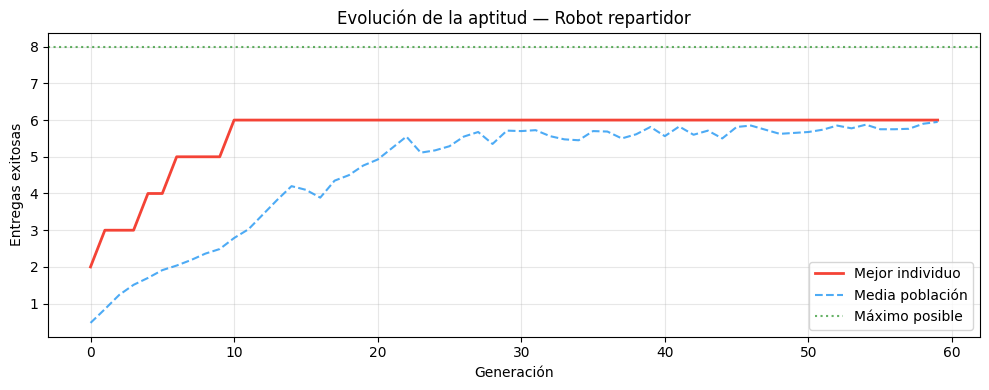

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historial_mejor, color="#F44336", linewidth=2, label="Mejor individuo")
ax.plot(historial_media, color="#2196F3", linewidth=1.5, linestyle="--",
        alpha=0.8, label="Media población")
ax.axhline(len(INGENIEROS), color="green", linestyle=":", alpha=0.6, label="Máximo posible")
ax.set_xlabel("Generación")
ax.set_ylabel("Entregas exitosas")
ax.set_title("Evolución de la aptitud — Robot repartidor")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_pg.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Visualización del mejor recorrido

C:\Users\Juan Tinjaca\AppData\Local\Temp\ipykernel_25280\3218620707.py:38: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Juan Tinjaca\AppData\Local\Temp\ipykernel_25280\3218620707.py:39: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("mejor_ruta.png", dpi=120, bbox_inches="tight")
C:\Users\Juan Tinjaca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


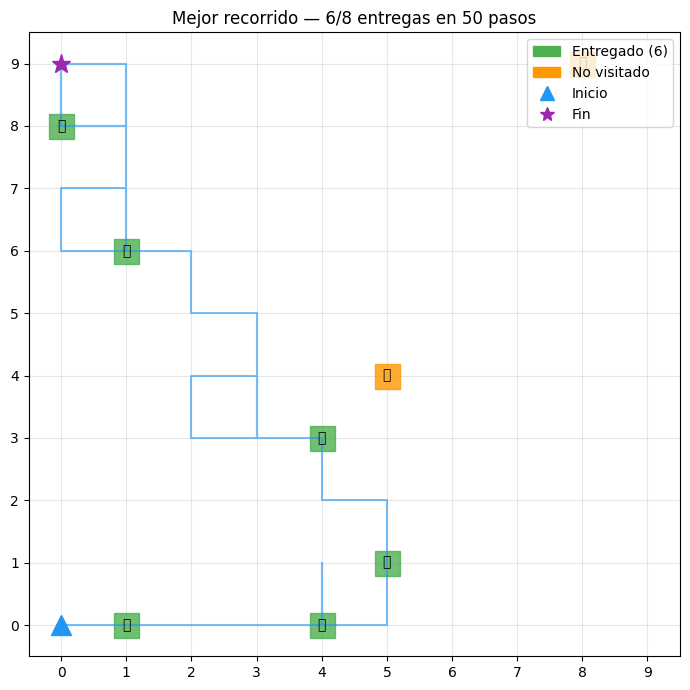

Árbol-programa del mejor individuo:
SEQ(REP3(ESTE), SEQ(SEQ(REP3(REP3(SEQ(ESTE, REP3(REP3(IF_INGENIERO(NORTE, SEQ(IF_INGENIERO(REP3(OESTE), SEQ(SEQ(SUR, ESTE), NORTE)), REP3(SEQ(NORTE, OESTE))))))))), SUR), SEQ(REP3(ESTE), ESTE)))


In [8]:
_, estado_mejor = evaluar(mejor_arbol)
ruta = estado_mejor.ruta

fig, ax = plt.subplots(figsize=(7, 7))

# Cuadrícula
ax.set_xlim(-0.5, GRID - 0.5)
ax.set_ylim(-0.5, GRID - 0.5)
ax.set_xticks(range(GRID))
ax.set_yticks(range(GRID))
ax.grid(True, alpha=0.3)

# Ingenieros
for (ix, iy) in INGENIEROS:
    color = "#4CAF50" if (ix, iy) in estado_mejor.entregados else "#FF9800"
    ax.plot(ix, iy, "s", markersize=18, color=color, alpha=0.8)
    ax.text(ix, iy, "👤", ha="center", va="center", fontsize=10)

# Ruta del robot
xs = [p[0] for p in ruta]
ys = [p[1] for p in ruta]
ax.plot(xs, ys, "-", color="#2196F3", linewidth=1.5, alpha=0.6, zorder=2)
ax.plot(xs[0], ys[0], "^", color="#2196F3", markersize=14, label="Inicio", zorder=3)
ax.plot(xs[-1], ys[-1], "*", color="#9C27B0", markersize=14, label="Fin", zorder=3)

# Leyenda
leyenda = [
    mpatches.Patch(color="#4CAF50", label=f"Entregado ({len(estado_mejor.entregados)})"),
    mpatches.Patch(color="#FF9800", label="No visitado"),
]
ax.legend(handles=leyenda + [
    plt.Line2D([0],[0], marker="^", color="#2196F3", label="Inicio", linestyle="None", markersize=10),
    plt.Line2D([0],[0], marker="*", color="#9C27B0", label="Fin",   linestyle="None", markersize=10),
], loc="upper right")

ax.set_title(f"Mejor recorrido — {len(estado_mejor.entregados)}/{len(INGENIEROS)} entregas "
             f"en {estado_mejor.pasos} pasos")
plt.tight_layout()
plt.savefig("mejor_ruta.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Árbol-programa del mejor individuo:")
print(mejor_arbol)

### 5.3 Análisis del mejor individuo

In [9]:
print("=" * 55)
print("ANÁLISIS DEL MEJOR INDIVIDUO")
print("=" * 55)
print(f"Entregas logradas : {len(estado_mejor.entregados)} / {len(INGENIEROS)}")
print(f"Pasos utilizados  : {estado_mejor.pasos} / {MAX_PASOS}")
print(f"Eficiencia        : {len(estado_mejor.entregados)/estado_mejor.pasos*100:.1f}% (entregas/paso)")
print(f"Ingenieros visitados: {sorted(estado_mejor.entregados)}")
print(f"\nRepresentación del árbol-programa:")
print(f"  {mejor_arbol}")
print("=" * 55)

ANÁLISIS DEL MEJOR INDIVIDUO
Entregas logradas : 6 / 8
Pasos utilizados  : 50 / 50
Eficiencia        : 12.0% (entregas/paso)
Ingenieros visitados: [(0, 8), (1, 0), (1, 6), (4, 0), (4, 3), (5, 1)]

Representación del árbol-programa:
  SEQ(REP3(ESTE), SEQ(SEQ(REP3(REP3(SEQ(ESTE, REP3(REP3(IF_INGENIERO(NORTE, SEQ(IF_INGENIERO(REP3(OESTE), SEQ(SEQ(SUR, ESTE), NORTE)), REP3(SEQ(NORTE, OESTE))))))))), SUR), SEQ(REP3(ESTE), ESTE)))


### 5.4 Animación del recorrido

In [10]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

_, estado_anim = evaluar(mejor_arbol)
ruta_anim = estado_anim.ruta

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))

def init_anim():
    ax_anim.clear()
    ax_anim.set_xlim(-0.5, GRID - 0.5)
    ax_anim.set_ylim(-0.5, GRID - 0.5)
    ax_anim.set_xticks(range(GRID))
    ax_anim.set_yticks(range(GRID))
    ax_anim.grid(True, alpha=0.3)
    # Dibujar ingenieros (todos sin visitar al inicio)
    for (ix, iy) in INGENIEROS:
        ax_anim.plot(ix, iy, "s", markersize=18, color="#FF9800", alpha=0.8)
        ax_anim.text(ix, iy, "👤", ha="center", va="center", fontsize=10)
    ax_anim.set_title("Animación del recorrido — paso 0")
    return []

def update_anim(frame):
    ax_anim.clear()
    ax_anim.set_xlim(-0.5, GRID - 0.5)
    ax_anim.set_ylim(-0.5, GRID - 0.5)
    ax_anim.set_xticks(range(GRID))
    ax_anim.set_yticks(range(GRID))
    ax_anim.grid(True, alpha=0.3)

    # Posiciones visitadas hasta este frame
    visitados = set(ruta_anim[:frame + 1])
    entregados_frame = visitados & set(INGENIEROS)

    # Ingenieros
    for (ix, iy) in INGENIEROS:
        color = "#4CAF50" if (ix, iy) in entregados_frame else "#FF9800"
        ax_anim.plot(ix, iy, "s", markersize=18, color=color, alpha=0.85)
        ax_anim.text(ix, iy, "👤", ha="center", va="center", fontsize=10)

    # Estela de la ruta recorrida
    if frame > 0:
        xs = [p[0] for p in ruta_anim[:frame + 1]]
        ys = [p[1] for p in ruta_anim[:frame + 1]]
        ax_anim.plot(xs, ys, "-", color="#2196F3", linewidth=1.5, alpha=0.5, zorder=2)

    # Robot (posición actual)
    rx, ry = ruta_anim[frame]
    ax_anim.plot(rx, ry, "o", markersize=14, color="#E91E63", zorder=5)
    ax_anim.text(rx, ry, "🤖", ha="center", va="center", fontsize=11, zorder=6)

    # Punto de inicio
    ax_anim.plot(ruta_anim[0][0], ruta_anim[0][1], "^",
                 markersize=10, color="#2196F3", zorder=4)

    ax_anim.set_title(
        f"Paso {frame} / {len(ruta_anim)-1}  —  "
        f"Entregas: {len(entregados_frame)}/{len(INGENIEROS)}"
    )
    return []

anim = FuncAnimation(
    fig_anim, update_anim,
    frames=len(ruta_anim),
    init_func=init_anim,
    interval=120,   # ms entre frames
    blit=False,
    repeat=True,
)

plt.close(fig_anim)  # evita mostrar figura estática duplicada
HTML(anim.to_jshtml())

C:\Users\Juan Tinjaca\AppData\Local\Temp\ipykernel_25280\4101493679.py:72: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
C:\Users\Juan Tinjaca\AppData\Local\Temp\ipykernel_25280\4101493679.py:72: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())


## 6. Conclusión

La programación genética logra evolucionar árboles-programa que controlan al robot de forma cada vez más eficiente, sin que el diseñador especifique explícitamente la estrategia de navegación. La clave del enfoque está en la representación: los terminales definen el vocabulario de acciones atómicas y las funciones definen las estructuras de control que combinan esas acciones. La función `IF_INGENIERO` permite al robot tomar decisiones contextuales, mientras que `REP3` y `SEQ` permiten construir secuencias más largas a partir de árboles compactos. El cruce de subárboles preserva bloques de comportamiento útiles entre generaciones, y la mutación introduce diversidad para escapar de óptimos locales. Este taller ilustra cómo la PG puede resolver problemas de planificación de rutas sin requerir un modelo matemático explícito del espacio de búsqueda.

---

## Referencias

- Koza, J. R. (1992). *Genetic Programming*. MIT Press.
- Poli, R., Langdon, W. B. & McPhee, N. F. (2008). *A Field Guide to Genetic Programming*. Lulu Press.
- Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.